# GBM Grid Search - S&P 500 Equity Straddles

This notebook tests whether gradient boosting finds non-linear structure in
equity-straddle returns beyond the regularized linear benchmark. It searches tree
depth and loss function, selects checkpoints on a sealed walk-forward validation
timeline, and registers complete predictions for downstream simulation.

**Learning Objectives**:
- Compare non-linear and linear validation IC on the same return-to-expiry label
- Separate tree-depth sensitivity from loss-function sensitivity
- Diagnose checkpoint overfitting without using the final holdout
- Generate backtesting-ready predictions with reproducible provenance

**Book Reference**: Chapter 12, Section 12.2 (GBM Libraries)

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb),
[`04_model_based_features`](04_model_based_features.ipynb), and
[`06_linear`](06_linear.ipynb)

In [1]:
"""GBM Grid Search - fold-safe, config-driven LightGBM validation."""

import hashlib
import os
import time
import warnings
from datetime import UTC, datetime
from pathlib import Path

import lightgbm as lgb
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
import torch  # Load its bundled CUDA runtime before ml4t.diagnostic imports.
import yaml
from IPython.display import Markdown, display
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from scipy import stats

In [2]:
from case_studies.utils.gbm import prepare_gbm_folds, train_gbm_config
from case_studies.utils.registry import (
    build_training_spec,
    canonical_json,
    get_training_dir,
    load_prediction_index,
    load_prediction_metrics,
    load_prediction_sets,
    load_preset,
    prediction_hash_from_parts,
    register_prediction_set,
    register_training_run,
    training_hash_from_spec,
    training_run_status,
)
from utils.artifact_specs import load_feature_spec, load_label_spec, resolve_storage_path
from utils.cv_splits import generate_cv_splits
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [3]:
SEED = 42
CASE_STUDY_ID = "sp500_options"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
MAX_FOLDS = 0
FORCE_RETRAIN = False
PREDICTION_SPLIT = "validation"
TRAIN_SAMPLE_FRAC = 1.0
DEVICE = "cpu"
MAX_BIN = 255
HAC_LAGS = 20
TRAINING_IDENTITY_VERSION = "sp500-options-gbm-normal-hac-physical-curves-v2"
EXPECTED_CONFIG_COUNT = 15
EXPECTED_CHECKPOINT_COUNT = 10
EXPECTED_HYPOTHESIS_COUNT = 150
CURVE_COLUMNS = [
    "config",
    "iteration",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "ic_se_hac",
    "ic_ci_lo",
    "ic_ci_hi",
    "ic_t_hac",
    "ic_p_hac",
    "ic_hac_lag",
]

warnings.filterwarnings("ignore")
set_global_seeds(SEED)

In [4]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

print(
    f"Case study: {CASE_STUDY_ID} | Device: {DEVICE} | max_bin: {MAX_BIN} | deterministic CPU path"
)

Case study: sp500_options | Device: cpu | max_bin: 255 | deterministic CPU path


Preservation runs write only to an isolated output tree. The guard below rejects
symlink, path-escape, and hard-link aliases before registry or model artifacts can
be written.

In [5]:
def _same_inode(left: Path, right: Path) -> bool:
    """Return whether two existing paths address the same filesystem object."""
    return left.exists() and right.exists() and os.path.samefile(left, right)

In [6]:
def _assert_isolated_path(path: Path, root: Path, canonical: Path) -> None:
    """Reject symlink, escape, and hard-link aliases for one write path."""
    absolute, root_absolute = path.absolute(), root.absolute()
    try:
        relative = absolute.relative_to(root_absolute)
    except ValueError as error:
        raise RuntimeError(f"Isolated path is outside its declared root: {path.name}") from error
    if root_absolute.is_symlink():
        raise RuntimeError(f"Isolated root is a symlink: {root.name}")
    current = root_absolute
    for component in relative.parts:
        current = current / component
        if current.is_symlink():
            raise RuntimeError(f"Isolated write path contains a symlink: {path.name}")
    resolved = path.resolve()
    resolved_root = root.resolve()
    if resolved != resolved_root and resolved_root not in resolved.parents:
        raise RuntimeError(f"Isolated write path resolves outside ML4T_OUTPUT_DIR: {path.name}")
    if path.is_file() and path.stat().st_nlink > 1:
        raise RuntimeError(f"Isolated regular file has multiple hard links: {path.name}")
    if _same_inode(path, canonical):
        raise RuntimeError(f"Isolated write path aliases the canonical registry: {path.name}")

In [7]:
def _require_isolated_registry(case_dir: Path) -> None:
    """Fail closed when a preservation run could reach the frozen registry."""
    if os.environ.get("ML4T_PRESERVE_REGISTRY") != "1":
        return
    output_root = os.environ.get("ML4T_OUTPUT_DIR")
    if not output_root:
        raise RuntimeError("Preservation runs require ML4T_OUTPUT_DIR")
    expected = Path(output_root).absolute() / CASE_STUDY_ID
    if case_dir.absolute() != expected or case_dir.is_symlink():
        raise RuntimeError("Case-study output is not a real isolated directory")
    canonical = Path(os.environ["ML4T_CANONICAL_CASE_DIR"]).resolve()
    if _same_inode(case_dir, canonical):
        raise RuntimeError("Case-study output aliases the canonical case directory")
    run_log = case_dir / "run_log"
    _assert_isolated_path(run_log, expected, canonical / "run_log")
    run_log.mkdir(parents=True, exist_ok=True)
    for name in ("training", "predictions"):
        child = run_log / name
        _assert_isolated_path(child, run_log, canonical / "run_log" / name)
        child.mkdir(exist_ok=True)
    for child in run_log.rglob("*"):
        relative = child.relative_to(run_log)
        _assert_isolated_path(child, run_log, canonical / "run_log" / relative)

In [8]:
_require_isolated_registry(CASE_DIR)

## 1. Load the corrected modeling artifacts

The label is known only at option expiry. We therefore rebuild the canonical folds,
reject any window touching the holdout, and remove pre-holdout decisions whose
actual expiry reaches 2021.

In [9]:
def _validate_cv_splits(cv_splits: list[dict], holdout_start: str) -> None:
    """Reject inverted, overlapping, or holdout-contaminated CV windows."""
    fold_ids = [int(split["fold"]) for split in cv_splits]
    if fold_ids != list(range(len(cv_splits))):
        raise ValueError(f"Canonical CV fold IDs must be 0..N-1, got {fold_ids}")
    holdout = pd.Timestamp(holdout_start)
    for split in cv_splits:
        train_end = pd.Timestamp(split["train_end"])
        val_start = pd.Timestamp(split["val_start"])
        val_end = pd.Timestamp(split["val_end"])
        if train_end >= val_start:
            raise ValueError(f"Fold {split['fold']} training overlaps validation")
        if val_end >= holdout:
            raise ValueError(f"Fold {split['fold']} reaches the sealed holdout")

In [10]:
def _seal_label_endpoints(
    dataset: pl.DataFrame,
    date_col: str,
    holdout_start: str,
) -> pl.DataFrame:
    """Keep only rows whose full label endpoint precedes the holdout."""
    if "dte_calendar" not in dataset.columns:
        raise ValueError("Return-to-expiry labels require dte_calendar")
    if dataset["dte_calendar"].null_count():
        raise ValueError("Return-to-expiry labels have null expiry horizons")
    if dataset.filter(pl.col("dte_calendar") < 0).height:
        raise ValueError("Return-to-expiry labels have negative expiry horizons")
    holdout = pd.Timestamp(holdout_start).date()
    sealed = dataset.with_columns(
        (pl.col(date_col) + pl.duration(days=pl.col("dte_calendar"))).alias("_label_end")
    )
    return sealed.filter(pl.col("_label_end") < holdout).drop("_label_end")

Fold-specific GARCH and stochastic-volatility features use estimator identity as
part of their key. Fold `-1` belongs to the sealed holdout and is never eligible
for checkpoint or model selection.

In [11]:
def _validate_temporal_keys(
    temporal: pl.DataFrame,
    date_col: str,
    entity_col: str,
    temporal_features: list[str],
) -> None:
    """Reject incomplete or ambiguous fold-specific temporal keys."""
    keys = [date_col, entity_col, "fold"]
    missing = set(keys + temporal_features).difference(temporal.columns)
    if missing:
        raise ValueError(f"Temporal artifact is missing columns: {sorted(missing)}")
    null_keys = temporal.select(pl.any_horizontal([pl.col(k).is_null() for k in keys]).sum()).item()
    if null_keys:
        raise ValueError(f"Temporal artifact has {null_keys} rows with null keys")
    duplicates = temporal.group_by(keys).len().filter(pl.col("len") > 1).height
    if duplicates:
        raise ValueError(f"Temporal artifact has {duplicates} duplicate fold-specific keys")

In [12]:
def _count_invalid_temporal(aligned: pl.DataFrame, features: list[str]) -> int:
    """Count invalid estimates among rows that matched a temporal key."""
    invalid = [pl.col(name).is_null() | pl.col(name).is_infinite() for name in features]
    return (
        aligned.filter(pl.col("_temporal_match").is_not_null())
        .select(pl.any_horizontal(invalid).sum())
        .item()
    )

In [13]:
def _align_temporal_fold(
    base: pl.DataFrame,
    temporal: pl.DataFrame,
    split: dict,
    date_col: str,
    entity_col: str,
    temporal_features: list[str],
) -> pl.DataFrame:
    """Join one estimator fold to its exact training and validation rows."""
    fold_id = int(split["fold"])
    if fold_id < 0:
        raise ValueError("Holdout estimates cannot enter cross-validation")
    bounds = {
        name: pd.Timestamp(split[name]).date() if base.schema[date_col] == pl.Date else split[name]
        for name in ("train_start", "train_end", "val_start", "val_end")
    }
    train = pl.col(date_col).is_between(bounds["train_start"], bounds["train_end"], closed="both")
    val = pl.col(date_col).is_between(bounds["val_start"], bounds["val_end"], closed="both")
    rows = base.filter(train | val).with_columns(pl.lit(fold_id).alias("fold"))
    keys = [date_col, entity_col, "fold"]
    estimates = temporal.filter(pl.col("fold") == fold_id).select(
        [*keys, *temporal_features, pl.lit(1).alias("_temporal_match")]
    )
    aligned = rows.join(estimates, on=keys, how="left", validate="1:1")
    coverage = 1.0 - (missing := aligned["_temporal_match"].null_count()) / len(aligned)
    if coverage < 0.95:
        raise ValueError(f"Fold {fold_id} temporal coverage is only {coverage:.1%}")
    if missing:
        print(f"  Fold {fold_id}: {coverage:.1%} temporal coverage")
    invalid = _count_invalid_temporal(aligned, temporal_features)
    if invalid:
        raise ValueError(f"Fold {fold_id} has {invalid} invalid matched temporal rows")
    return aligned.drop("_temporal_match")

Registry identities bind the exact input bytes and every validation boundary. A
cache made from another artifact vintage or fold map cannot masquerade as a hit.

In [14]:
def _modeling_artifact_paths(case_study_id: str, label: str) -> dict[str, Path]:
    """Resolve the exact parquets consumed by the modeling loader."""
    financial = load_feature_spec(case_study_id, "financial")
    temporal = load_feature_spec(case_study_id, "model_based")
    label_spec = load_label_spec(case_study_id, label)
    return {
        "financial": resolve_storage_path(case_study_id, financial, "features/financial.parquet"),
        "model_based": resolve_storage_path(
            case_study_id, temporal, "features/model_based.parquet"
        ),
        "label": resolve_storage_path(case_study_id, label_spec, f"labels/{label}.parquet"),
    }

In [15]:
def _artifact_identity(paths: dict[str, Path]) -> dict[str, dict[str, int | str]]:
    """Hash exact input bytes and reject files that change while being read."""
    identity = {}
    for name, path in sorted(paths.items()):
        before = path.stat()
        digest = hashlib.sha256()
        with path.open("rb") as stream:
            for chunk in iter(lambda: stream.read(1024 * 1024), b""):
                digest.update(chunk)
        after = path.stat()
        before_state = (before.st_dev, before.st_ino, before.st_size, before.st_mtime_ns)
        after_state = (after.st_dev, after.st_ino, after.st_size, after.st_mtime_ns)
        if before_state != after_state:
            raise RuntimeError(f"Input artifact changed while hashing: {name}")
        identity[name] = {"sha256": digest.hexdigest(), "size_bytes": after.st_size}
    return identity

In [16]:
def _evaluation_identity(cv_splits: list[dict], label_buffer: str) -> dict:
    """Serialize every boundary that determines the validation design."""
    keys = ("train_start", "train_end", "val_start", "val_end")
    bounds = [
        {"fold": int(s["fold"]), **{key: pd.Timestamp(s[key]).isoformat() for key in keys}}
        for s in cv_splits
    ]
    return {
        "label_buffer": str(label_buffer),
        "holdout_start": setup["evaluation"]["holdout_start"],
        "holdout_end": setup["evaluation"]["holdout_end"],
        "splits": bounds,
    }

In [17]:
def _config_identity(cfg: dict) -> dict:
    """Return every resolved model field that can alter the fit."""
    return {
        "family": str(cfg["family"]),
        "config_name": str(cfg["config_name"]),
        "library": str(cfg["library"]),
        "params": dict(cfg["params"]),
        "max_iterations": int(cfg.get("max_iterations", 500)),
        "checkpoint_interval": int(cfg.get("checkpoint_interval", 50)),
    }

In [18]:
def _resolved_runtime_config(cfg: dict) -> dict:
    """Resolve the exact configuration passed through to LightGBM."""
    resolved = _config_identity(cfg)
    resolved["params"].update(
        {
            "deterministic": True,
            "force_col_wise": True,
            "metric": "None",
            "verbosity": resolved["params"].get("verbosity", -1),
            "max_bin": MAX_BIN,
        }
    )
    return resolved

In [19]:
def _assert_preset_matches(cfg: dict) -> None:
    """Reject disagreement between the training menu and shared preset."""
    preset = load_preset(str(cfg["family"]), str(cfg["config_name"]))
    if canonical_json(_config_identity(cfg)) != canonical_json(_config_identity(preset)):
        raise ValueError(f"Resolved config differs from preset: {cfg['config_name']}")

In [20]:
ARTIFACT_PATHS = _modeling_artifact_paths(CASE_STUDY_ID, PRIMARY_LABEL)
ARTIFACT_HASHES = _artifact_identity(ARTIFACT_PATHS)
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
if _artifact_identity(ARTIFACT_PATHS) != ARTIFACT_HASHES:
    raise RuntimeError("Modeling artifacts changed while loading")

raw_dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else None
if entity_col is None:
    raise ValueError("S&P 500 options modeling requires a cross-sectional entity key")

In [21]:
canonical_splits = generate_cv_splits(
    raw_dataset,
    case_study_id=CASE_STUDY_ID,
    label_buffer=mds.label_buffer,
    date_col=date_col,
)
_validate_cv_splits(canonical_splits, setup["evaluation"]["holdout_start"])
splits = canonical_splits[: MAX_FOLDS or None]
dataset = _seal_label_endpoints(raw_dataset, date_col, setup["evaluation"]["holdout_start"])

print(f"Dataset: {len(dataset):,} rows x {len(feature_names)} features")
print(f"Label: {label_col} | Task: {mds.task_type} | CV folds: {len(splits)}")

Dataset: 274,069 rows x 52 features
Label: ret_to_expiry | Task: regression | CV folds: 2


In [22]:
configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, family="gbm")
if len(configs) != EXPECTED_CONFIG_COUNT:
    raise ValueError(f"Expected {EXPECTED_CONFIG_COUNT} GBM configs, found {len(configs)}")
for config in configs:
    _assert_preset_matches(config)
print(f"Grid: {len(configs)} configurations x {len(splits)} folds")

config_table = pl.DataFrame(
    {
        "configuration": [cfg["config_name"] for cfg in configs],
        "leaves": [cfg["params"].get("num_leaves", 31) for cfg in configs],
        "objective": [cfg["params"].get("objective", "regression") for cfg in configs],
        "trees": [cfg.get("max_iterations", 500) for cfg in configs],
    }
)
config_table

Grid: 15 configurations x 2 folds


configuration,leaves,objective,trees
str,i64,str,i64
"""leaves_31_mae""",31,"""regression_l1""",500
"""leaves_7_huber""",7,"""huber""",500
"""leaves_7_mae""",7,"""regression_l1""",500
"""leaves_15_mae""",15,"""regression_l1""",500
"""default_mae""",31,"""regression_l1""",500
…,…,…,…
"""leaves_63_mae""",63,"""regression_l1""",500
"""default_huber""",31,"""huber""",500
"""leaves_63_huber""",63,"""huber""",500


## 2. Prepare exact walk-forward folds

Each split receives only the temporal estimates fitted for that split. LightGBM
needs no fitted scaler or imputer; missing predictors remain explicit and are
handled by its learned split direction using training data only.

In [23]:
if mds.temporal_by_fold is None or not mds.temporal_feature_names:
    raise ValueError("Fold-specific temporal features are required")
temporal = pl.from_pandas(mds.temporal_by_fold)
_validate_temporal_keys(temporal, date_col, entity_col, mds.temporal_feature_names)
key_casts = {
    key: dataset.schema[key]
    for key in (date_col, entity_col)
    if temporal.schema[key] != dataset.schema[key]
}
if key_casts:
    temporal = temporal.cast(key_casts)

In [24]:
base_dataset = dataset.drop(mds.temporal_feature_names)
fold_data = []
for split in splits:
    aligned = _align_temporal_fold(
        base_dataset,
        temporal,
        split,
        date_col,
        entity_col,
        mds.temporal_feature_names,
    )
    prepared = prepare_gbm_folds(
        aligned.to_pandas(),
        [split],
        feature_names,
        label_col,
        date_col,
        entity_col,
        task_type=mds.task_type,
        class_values=mds.class_values,
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    if len(prepared) != 1:
        raise ValueError(f"Fold {split['fold']} did not produce exactly one prepared split")
    val_start, val_end = pd.Timestamp(split["val_start"]), pd.Timestamp(split["val_end"])
    val_rows = aligned.filter(pl.col(date_col).is_between(val_start, val_end, closed="both"))
    val_rows = val_rows.filter(pl.col(label_col).is_not_null())
    prepared[0]["meta"] = val_rows.select(mds.join_cols).to_pandas()
    fold_data.extend(prepared)

for fold in fold_data:
    print(f"  Fold {fold['fold']}: train={fold['n_train']:,}  validation={fold['n_val']:,}")

  Fold 0: 97.1% temporal coverage


  Fold 1: 96.7% temporal coverage


  Fold 0: train=141,355  validation=60,256
  Fold 1: train=125,902  validation=76,852


Completeness is defined before any model runs. Every configuration must predict the
same unique keys and produce finite daily IC on the same eligible dates.

In [25]:
def _expected_prediction_contract(
    prepared_folds: list[dict],
    join_cols: list[str],
    date_col: str,
    entity_col: str,
) -> tuple[pl.DataFrame, set]:
    """Build exact validation keys and eligible IC dates."""
    frames = []
    for fold in prepared_folds:
        if not np.isfinite(fold["y_val"]).all():
            raise ValueError(f"Fold {fold['fold']} has nonfinite validation labels")
        frames.append(
            pl.from_pandas(fold["meta"][join_cols]).with_columns(
                pl.lit(int(fold["fold"])).alias("fold"),
                pl.Series("actual", fold["y_val"]),
            )
        )
    keys = [*join_cols, "fold"]
    expected = pl.concat(frames).sort(keys)
    if expected.select(pl.any_horizontal([pl.col(k).is_null() for k in keys]).sum()).item():
        raise ValueError("Expected validation keys contain nulls")
    if expected.group_by(keys).len().filter(pl.col("len") > 1).height:
        raise ValueError("Expected validation keys are not unique")
    eligible = set(
        expected.group_by(date_col)
        .agg(pl.col(entity_col).n_unique().alias("n_entities"))
        .filter(pl.col("n_entities") >= 5)[date_col]
        .to_list()
    )
    if not eligible:
        raise ValueError("Validation design has no eligible IC dates")
    return expected, eligible

In [26]:
expected_prediction_keys, expected_ic_dates = _expected_prediction_contract(
    fold_data,
    mds.join_cols,
    date_col,
    entity_col,
)
expected_ic_days = len(expected_ic_dates)
print(
    f"Complete validation contract: {len(expected_prediction_keys):,} keys, {expected_ic_days} dates"
)

Complete validation contract: 137,108 keys, 484 dates


In [27]:
def _validate_prediction_keys(predictions: pl.DataFrame) -> pl.DataFrame:
    """Require exact, unique, finite prediction coverage and targets."""
    keys = [*mds.join_cols, "fold"]
    required = set(keys + ["prediction", "actual"])
    missing = required.difference(predictions.columns)
    if missing:
        raise ValueError(f"Predictions are missing columns: {sorted(missing)}")
    casts = {
        key: expected_prediction_keys.schema[key]
        for key in keys
        if predictions.schema[key] != expected_prediction_keys.schema[key]
    }
    if casts:
        predictions = predictions.cast(casts)
    invalid = predictions.select(
        pl.any_horizontal([pl.col(name).is_null() for name in required]).sum().alias("nulls"),
        pl.any_horizontal([pl.col(name).is_infinite() for name in ("prediction", "actual")])
        .sum()
        .alias("nonfinite"),
    ).row(0, named=True)
    if invalid["nulls"] or invalid["nonfinite"]:
        raise ValueError(f"Predictions contain invalid values: {invalid}")
    if predictions.group_by(keys).len().filter(pl.col("len") > 1).height:
        raise ValueError("Prediction keys are not unique")
    actual_keys = predictions.select(keys)
    missing_n = expected_prediction_keys.join(actual_keys, on=keys, how="anti").height
    extra_n = actual_keys.join(expected_prediction_keys, on=keys, how="anti").height
    if missing_n or extra_n:
        raise ValueError(f"Prediction coverage differs: missing={missing_n}, extra={extra_n}")
    check = predictions.join(
        expected_prediction_keys.select([*keys, pl.col("actual").alias("_expected")]),
        on=keys,
        how="left",
    )
    if not np.allclose(check["actual"], check["_expected"], rtol=1e-12, atol=1e-12):
        raise ValueError("Prediction targets differ from endpoint-sealed labels")
    return predictions.sort(keys)

In [28]:
def _normal_hac_inference(mean: float, se: float, t_stat: float) -> dict[str, float]:
    """Return the project-wide normal-reference HAC p-value and interval."""
    critical = float(stats.norm.ppf(0.975))
    return {
        "ic_ci_lo": float(mean - critical * se),
        "ic_ci_hi": float(mean + critical * se),
        "ic_p_hac": float(2 * stats.norm.sf(abs(t_stat))),
    }

In [29]:
def _daily_ic_summary(predictions: pl.DataFrame) -> tuple[dict, pl.DataFrame]:
    """Compute one sorted daily IC series and its fixed-lag HAC statistics."""
    ordered = predictions.sort([date_col, entity_col])
    daily = cross_sectional_ic_series(
        ordered,
        ordered,
        pred_col="prediction",
        ret_col="actual",
        date_col=date_col,
        entity_col=entity_col,
        method="spearman",
        min_obs=5,
    ).sort(date_col)
    daily = daily.drop_nulls("ic").filter(pl.col("ic").is_finite())
    actual_dates = set(daily[date_col].to_list())
    if actual_dates != expected_ic_dates:
        missing = len(expected_ic_dates - actual_dates)
        extra = len(actual_dates - expected_ic_dates)
        raise ValueError(f"Daily IC coverage differs: missing={missing}, extra={extra}")
    hac = compute_ic_hac_stats(daily, ic_col="ic", maxlags=HAC_LAGS)
    mean = float(hac["mean_ic"])
    se = float(hac["hac_se"])
    t_stat = float(hac["t_stat"])
    inference = _normal_hac_inference(mean, se, t_stat)
    summary = {
        "ic_mean": mean,
        "ic_std": float(daily["ic"].std()),
        "ic_n_days": int(hac["n_periods"]),
        "ic_se_hac": se,
        "ic_t_hac": t_stat,
        "ic_hac_lag": int(hac["effective_lags"]),
        **inference,
    }
    return summary, daily

## 3. Train and select checkpoints

Each configuration trains to its fixed tree budget on CPU with deterministic
LightGBM reductions. Checkpoint selection ranks the combined chronological daily
IC series, not an average of fold summary statistics. The 2021 holdout is absent.

In [30]:
def _training_spec(cfg: dict) -> dict:
    """Build a hash that binds configuration, bytes, folds, and execution mode."""
    resolved = _resolved_runtime_config(cfg)
    base = build_training_spec(
        resolved["family"],
        resolved["config_name"],
        label_col,
        n_folds=len(fold_data),
        checkpoint_interval=resolved["checkpoint_interval"],
        seed=SEED,
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    base.update(resolved)
    base["resolved_config"] = resolved
    base["resolved_config_json"] = canonical_json(resolved)
    base["input_identity"] = {
        "version": TRAINING_IDENTITY_VERSION,
        "artifacts": ARTIFACT_HASHES,
        "evaluation": _evaluation_identity(splits, mds.label_buffer),
        "selection": _selection_identity(),
        "fitted_features": {
            "count": len(feature_names),
            "ordered_names": list(feature_names),
        },
        "execution": {
            "device": DEVICE,
            "max_bin": MAX_BIN,
            "hac_lags": HAC_LAGS,
            "hac_reference": "normal",
        },
    }
    return base

In [31]:
def _selection_identity() -> dict[str, int | str | float]:
    """Bind optional row and fold reductions that alter the fitted sample."""
    symbols = sorted(str(value) for value in dataset[entity_col].unique().to_list())
    symbol_digest = hashlib.sha256("\n".join(symbols).encode()).hexdigest()
    return {
        "max_symbols": int(MAX_SYMBOLS),
        "max_folds": int(MAX_FOLDS),
        "train_sample_frac": float(TRAIN_SAMPLE_FRAC),
        "n_rows": len(dataset),
        "n_symbols": len(symbols),
        "symbols_sha256": symbol_digest,
    }

In [32]:
def _checkpoint_panel(raw_result: dict, checkpoint: int) -> pl.DataFrame:
    """Assemble and validate one checkpoint's complete prediction panel."""
    frames = []
    for entry in raw_result["predictions"]:
        if int(entry["n_trees"]) != checkpoint:
            continue
        frames.append(
            pl.DataFrame(
                {
                    date_col: entry["dates"],
                    entity_col: entry["entities"],
                    "fold": [int(entry["fold"])] * len(entry["y_pred"]),
                    "prediction": entry["y_pred"],
                    "actual": entry["y_true"],
                }
            )
        )
    selected = [entry for entry in raw_result["predictions"] if int(entry["n_trees"]) == checkpoint]
    selected_folds = sorted(int(entry["fold"]) for entry in selected)
    expected_folds = sorted(int(fold["fold"]) for fold in fold_data)
    if len(frames) != len(fold_data) or selected_folds != expected_folds:
        raise ValueError(f"Checkpoint {checkpoint} does not cover every fold")
    panel = pl.concat(frames)
    missing_keys = [key for key in mds.join_cols if key not in panel.columns]
    if missing_keys:
        lookup_keys = [date_col, entity_col, "fold"]
        lookup = expected_prediction_keys.select([*lookup_keys, *missing_keys])
        panel = panel.join(lookup, on=lookup_keys, how="left", validate="1:1")
    return _validate_prediction_keys(panel)

In [33]:
def _prediction_cache_path(prediction_hash: str) -> Path:
    """Resolve and recheck one physical prediction artifact."""
    path = CASE_DIR / "run_log/predictions" / prediction_hash / "predictions.parquet"
    relative = path.relative_to(CASE_DIR / "run_log")
    if os.environ.get("ML4T_PRESERVE_REGISTRY") == "1":
        canonical_root = Path(os.environ["ML4T_CANONICAL_CASE_DIR"]).resolve() / "run_log"
    else:
        canonical_root = CASE_DIR / "run_log/.canonical-alias-disabled"
    _assert_isolated_path(path, CASE_DIR / "run_log", canonical_root / relative)
    return path

In [34]:
def _training_cache_path(training_hash: str, filename: str) -> Path:
    """Resolve and recheck one physical training artifact."""
    path = CASE_DIR / "run_log/training" / training_hash / filename
    relative = path.relative_to(CASE_DIR / "run_log")
    if os.environ.get("ML4T_PRESERVE_REGISTRY") == "1":
        canonical_root = Path(os.environ["ML4T_CANONICAL_CASE_DIR"]).resolve() / "run_log"
    else:
        canonical_root = CASE_DIR / "run_log/.canonical-alias-disabled"
    _assert_isolated_path(path, CASE_DIR / "run_log", canonical_root / relative)
    return path

In [35]:
def _validate_cached_metrics(prediction_hash: str, current: dict) -> None:
    """Require stored metrics to match the physical prediction artifact."""
    metrics = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=prediction_hash)
    expected = _metric_payload(current)
    required = {"prediction_hash", *expected}
    if metrics.height != 1 or not required.issubset(metrics.columns):
        raise ValueError("cache has no unique complete metric row")
    row = metrics.row(0, named=True)
    if row["prediction_hash"] != prediction_hash:
        raise ValueError("cache metric row has the wrong prediction hash")
    for name, value in expected.items():
        stored = row[name]
        if stored is None or not np.isfinite(float(stored)):
            raise ValueError(f"cache metric {name} is missing or nonfinite")
        if not np.isclose(float(stored), float(value), rtol=1e-12, atol=1e-12):
            raise ValueError(f"cache metric {name} differs from physical predictions")

In [36]:
def _read_cached_result(cfg: dict, spec: dict, status) -> dict | None:
    """Return a fully validated cache hit, or None when retraining is required."""
    if FORCE_RETRAIN or not status.complete:
        return None
    training_hash = training_hash_from_spec(spec)
    rows = load_prediction_sets(CASE_STUDY_ID, training_hash=training_hash, split=PREDICTION_SPLIT)
    if rows.height != 1:
        raise ValueError(f"{cfg['config_name']}: cache has {rows.height} validation rows")
    row = rows.row(0, named=True)
    checkpoint = row.get("checkpoint_value")
    if checkpoint is None or row.get("checkpoint_kind") != "tree_limit":
        raise ValueError(f"{cfg['config_name']}: cache is not a tree checkpoint")
    prediction_hash = row.get("prediction_hash")
    expected_hash = prediction_hash_from_parts(training_hash, int(checkpoint), PREDICTION_SPLIT)
    if prediction_hash != expected_hash:
        raise ValueError(f"{cfg['config_name']}: cache prediction hash is forged")
    path = _prediction_cache_path(str(prediction_hash))
    if not path.is_file():
        return None
    path = _prediction_cache_path(str(prediction_hash))
    predictions = _validate_prediction_keys(pl.read_parquet(path))
    summary, _ = _daily_ic_summary(predictions)
    _validate_cached_metrics(str(prediction_hash), summary)
    curves = _read_cached_curves(cfg, training_hash, int(checkpoint), summary)
    return {
        "config": cfg,
        "training_hash": training_hash,
        "best_iter": int(checkpoint),
        "predictions": predictions,
        "learning_curves": curves.to_dicts(),
        **summary,
        "cached": True,
    }

In [37]:
def _require_array_close(name: str, observed, expected) -> None:
    """Reject a cached numeric vector that differs from its physical oracle."""
    if not np.allclose(observed, expected, rtol=1e-12, atol=1e-12):
        raise ValueError(f"cache curve {name} differs from physical arithmetic")

In [38]:
def _validate_curve_frame(cfg: dict, curves: pl.DataFrame) -> pl.DataFrame:
    """Validate schema, coverage, and normal-HAC arithmetic for ten checkpoints."""
    if curves.columns != CURVE_COLUMNS:
        raise ValueError(f"{cfg['config_name']}: cache learning-curve columns differ")
    curves = curves.sort("iteration")
    if curves["iteration"].to_list() != _expected_checkpoints(cfg):
        raise ValueError(f"{cfg['config_name']}: cache learning curve is incomplete")
    if set(curves["config"].to_list()) != {cfg["config_name"]}:
        raise ValueError(f"{cfg['config_name']}: cache curve has a foreign config")
    numeric = [name for name in CURVE_COLUMNS if name != "config"]
    if curves.select(pl.any_horizontal([pl.col(name).is_null() for name in numeric]).sum()).item():
        raise ValueError(f"{cfg['config_name']}: cache curve has null values")
    if curves.select(
        pl.any_horizontal([pl.col(name).is_infinite() for name in numeric]).sum()
    ).item():
        raise ValueError(f"{cfg['config_name']}: cache curve has nonfinite values")
    if set(curves["ic_n_days"].to_list()) != {expected_ic_days}:
        raise ValueError(f"{cfg['config_name']}: cache curve has incomplete IC dates")
    if set(curves["ic_hac_lag"].to_list()) != {HAC_LAGS}:
        raise ValueError(f"{cfg['config_name']}: cache curve has the wrong HAC lag")
    mean, se, t_stat = (curves[name].to_numpy() for name in ("ic_mean", "ic_se_hac", "ic_t_hac"))
    critical = float(stats.norm.ppf(0.975))
    _require_array_close("t statistic", t_stat, mean / se)
    _require_array_close("normal p-value", curves["ic_p_hac"], 2 * stats.norm.sf(abs(t_stat)))
    _require_array_close("normal lower CI", curves["ic_ci_lo"], mean - critical * se)
    _require_array_close("normal upper CI", curves["ic_ci_hi"], mean + critical * se)
    return curves

In [39]:
def _validate_curve_selection(curves: pl.DataFrame, checkpoint: int, summary: dict) -> None:
    """Require the registered checkpoint to be the unique physical curve maximum."""
    peak = float(curves["ic_mean"].max())
    leaders = curves.filter(pl.col("ic_mean") == peak)
    if leaders.height != 1 or int(leaders["iteration"][0]) != checkpoint:
        raise ValueError("cached checkpoint is not the unique learning-curve maximum")
    selected = curves.filter(pl.col("iteration") == checkpoint).row(0, named=True)
    for name in CURVE_COLUMNS[2:]:
        if not np.isclose(float(selected[name]), float(summary[name]), rtol=1e-12, atol=1e-12):
            raise ValueError(f"selected cache curve {name} differs from physical predictions")

In [40]:
def _cached_booster_raw(cfg: dict, training_hash: str) -> dict:
    """Recompute all checkpoint-fold predictions from the two physical boosters."""
    entries = []
    for fold in fold_data:
        fold_id = int(fold["fold"])
        path = _training_cache_path(training_hash, f"boosters/fold_{fold_id}.txt")
        if not path.is_file():
            raise ValueError(f"{cfg['config_name']}: cache has no fold {fold_id} booster")
        path = _training_cache_path(training_hash, f"boosters/fold_{fold_id}.txt")
        booster = lgb.Booster(model_file=str(path))
        if booster.feature_name() != feature_names:
            raise ValueError(f"{cfg['config_name']}: booster feature order differs")
        for checkpoint in _expected_checkpoints(cfg):
            entries.append(
                {
                    "fold": fold_id,
                    "n_trees": checkpoint,
                    "y_pred": booster.predict(fold["X_val"], num_iteration=checkpoint),
                    "y_true": fold["y_val"],
                    "dates": fold["dates"],
                    "entities": fold["entities"],
                }
            )
    return {"predictions": entries}

In [41]:
def _recompute_cached_curves(cfg: dict, training_hash: str) -> pl.DataFrame:
    """Score the complete physical checkpoint family from saved boosters."""
    curves, _ = _score_checkpoints(cfg, _cached_booster_raw(cfg, training_hash))
    return pl.DataFrame(curves).select(CURVE_COLUMNS)

In [42]:
def _reconcile_curve_frames(stored: pl.DataFrame, physical: pl.DataFrame) -> None:
    """Require every stored checkpoint statistic to equal its booster recomputation."""
    if (
        stored.select(["config", "iteration"]).to_dicts()
        != physical.select(["config", "iteration"]).to_dicts()
    ):
        raise ValueError("cache curve keys differ from physical booster curves")
    for name in CURVE_COLUMNS[2:]:
        _require_array_close(name, stored[name].to_numpy(), physical[name].to_numpy())

In [43]:
def _read_cached_curves(
    cfg: dict, training_hash: str, checkpoint: int, summary: dict
) -> pl.DataFrame:
    """Validate persisted curves against all physical checkpoint predictions."""
    path = _training_cache_path(training_hash, "learning_curves.parquet")
    if not path.is_file():
        raise ValueError(f"{cfg['config_name']}: cache has no learning curve")
    stored = _validate_curve_frame(cfg, pl.read_parquet(path))
    physical = _validate_curve_frame(cfg, _recompute_cached_curves(cfg, training_hash))
    _reconcile_curve_frames(stored, physical)
    _validate_curve_selection(physical, checkpoint, summary)
    return physical

Fresh runs score every checkpoint against the exact same date and key oracle. Only
the winning checkpoint is retained as the registered prediction set; the full
learning curve remains as a compact training artifact.

In [44]:
def _fit_config(cfg: dict, spec: dict) -> dict:
    """Train one deterministic CPU configuration and select by daily IC."""
    runtime_cfg = _resolved_runtime_config(cfg)
    if canonical_json(runtime_cfg) != spec.get("resolved_config_json"):
        raise ValueError(f"Resolved config identity changed: {cfg['config_name']}")
    _require_isolated_registry(CASE_DIR)
    train_dir = get_training_dir(CASE_STUDY_ID, spec)
    started_at = datetime.now(UTC).isoformat()
    raw = train_gbm_config(
        runtime_cfg,
        fold_data,
        feature_names=feature_names,
        device=DEVICE,
        max_bin=MAX_BIN,
        entity_col=entity_col,
        date_col=date_col,
        task_type=mds.task_type,
        class_values=mds.class_values,
        save_dir=train_dir,
    )
    curves, panels = _score_checkpoints(cfg, raw)
    best_curve = max(curves, key=lambda row: row["ic_mean"])
    return {
        "config": cfg,
        "training_spec": spec,
        "training_hash": training_hash_from_spec(spec),
        "started_at": started_at,
        "elapsed_s": raw["elapsed_s"],
        "best_iter": int(best_curve["iteration"]),
        "predictions": panels[int(best_curve["iteration"])],
        "learning_curves": curves,
        "fold_metrics": raw.get("fold_metrics", []),
        "top_features": raw.get("top_features", []),
        **{key: value for key, value in best_curve.items() if key.startswith("ic_")},
    }

In [45]:
def _score_checkpoints(cfg: dict, raw: dict) -> tuple[list[dict], dict[int, pl.DataFrame]]:
    """Score every checkpoint on the combined chronological validation panel."""
    checkpoints = _validate_raw_checkpoint_grid(cfg, raw)
    curves, panels = [], {}
    for checkpoint in checkpoints:
        panel = _checkpoint_panel(raw, checkpoint)
        summary, _ = _daily_ic_summary(panel)
        panels[checkpoint] = panel
        curves.append({"config": cfg["config_name"], "iteration": checkpoint, **summary})
    return curves, panels

In [46]:
def _expected_checkpoints(cfg: dict) -> list[int]:
    """Derive the complete configured checkpoint sequence."""
    interval = int(cfg.get("checkpoint_interval", 50))
    maximum = int(cfg.get("max_iterations", 500))
    if interval <= 0 or maximum <= 0:
        raise ValueError("Checkpoint interval and tree budget must be positive")
    checkpoints = list(range(interval, maximum + 1, interval))
    if not checkpoints or checkpoints[-1] != maximum:
        checkpoints.append(maximum)
    if len(checkpoints) != EXPECTED_CHECKPOINT_COUNT:
        raise ValueError(
            f"Expected {EXPECTED_CHECKPOINT_COUNT} checkpoints, found {len(checkpoints)}"
        )
    return checkpoints

In [47]:
def _validate_raw_checkpoint_grid(cfg: dict, raw: dict) -> list[int]:
    """Reject missing, extra, or duplicate checkpoint-fold predictions."""
    expected = _expected_checkpoints(cfg)
    expected_folds = sorted(int(fold["fold"]) for fold in fold_data)
    observed = [int(item["n_trees"]) for item in raw.get("predictions", [])]
    if set(observed) != set(expected):
        missing = sorted(set(expected) - set(observed))
        extra = sorted(set(observed) - set(expected))
        raise ValueError(f"Checkpoint grid differs: missing={missing}, extra={extra}")
    if len(observed) != len(expected) * len(expected_folds):
        raise ValueError("Checkpoint grid has missing or duplicate fold predictions")
    for checkpoint in expected:
        folds = sorted(
            int(item["fold"]) for item in raw["predictions"] if int(item["n_trees"]) == checkpoint
        )
        if folds != expected_folds:
            raise ValueError(f"Checkpoint {checkpoint} fold coverage differs: {folds}")
    return expected

In [48]:
def _metric_payload(result: dict) -> dict[str, float | int]:
    """Map selected daily and HAC statistics to registry columns."""
    return {
        "ic_mean": result["ic_mean"],
        "ic_std": result["ic_std"],
        "ic_mean_daily": result["ic_mean"],
        "ic_std_daily": result["ic_std"],
        "ic_n_days": result["ic_n_days"],
        "ic_se_hac": result["ic_se_hac"],
        "ic_ci_lo": result["ic_ci_lo"],
        "ic_ci_hi": result["ic_ci_hi"],
        "ic_t_hac": result["ic_t_hac"],
        "ic_p_hac": result["ic_p_hac"],
        "ic_hac_lag": result["ic_hac_lag"],
    }

In [49]:
def _write_training_artifacts(result: dict, train_dir: Path) -> None:
    """Write compact curves and feature importance after isolation checks."""
    _require_isolated_registry(CASE_DIR)
    curves = pl.DataFrame(result["learning_curves"]).select(CURVE_COLUMNS)
    curves.write_parquet(train_dir / "learning_curves.parquet")
    if result["top_features"]:
        frame = pl.DataFrame(
            result["top_features"],
            schema=["feature", "importance"],
            orient="row",
        )
        frame.write_parquet(train_dir / "feature_importance.parquet")

In [50]:
def _register_result(result: dict) -> None:
    """Register a fresh config after rechecking identity and isolation."""
    if result.get("cached"):
        return
    spec = result["training_spec"]
    training_hash = result["training_hash"]
    if training_hash_from_spec(spec) != training_hash:
        raise ValueError("Training identity changed before registration")
    _require_isolated_registry(CASE_DIR)
    registered_hash = register_training_run(
        CASE_STUDY_ID,
        spec=spec,
        entry_point="07_gbm",
        started_at=result["started_at"],
        elapsed_s=result["elapsed_s"],
    )
    if registered_hash != training_hash:
        raise ValueError("Registry returned a different training hash")
    train_dir = CASE_DIR / "run_log/training" / training_hash
    _write_training_artifacts(result, train_dir)
    _require_isolated_registry(CASE_DIR)
    prediction_hash = register_prediction_set(
        CASE_STUDY_ID,
        training_hash,
        checkpoint_value=result["best_iter"],
        checkpoint_kind="tree_limit",
        split=PREDICTION_SPLIT,
        predictions=result["predictions"],
        metrics=_metric_payload(result),
        task_type=mds.task_type,
        class_values=mds.class_values or None,
        label=label_col,
    )
    expected_hash = prediction_hash_from_parts(training_hash, result["best_iter"], PREDICTION_SPLIT)
    if prediction_hash != expected_hash:
        raise ValueError("Registry returned a forged prediction hash")

In [51]:
results = []
for cfg in configs:
    spec = _training_spec(cfg)
    status = training_run_status(CASE_STUDY_ID, spec)
    try:
        result = _read_cached_result(cfg, spec, status)
    except (OSError, ValueError) as error:
        print(f"  {cfg['config_name']:25s}  RETRAIN - {error}")
        result = None
    if result is None:
        result = _fit_config(cfg, spec)
        _register_result(result)
    source = "cached" if result.get("cached") else f"{result['elapsed_s']:.0f}s"
    print(
        f"  {cfg['config_name']:25s}  trees={result['best_iter']:3d}  "
        f"IC={result['ic_mean']:+.4f}  HAC t={result['ic_t_hac']:+.2f}  ({source})"
    )
    result.pop("predictions", None)
    results.append(result)

      fold 0: training n_train=141,355 n_val=60,256 trees=500 num_leaves=31 obj=regression_l1


      fold 0: done in 10s


      fold 1: training n_train=125,902 n_val=76,852 trees=500 num_leaves=31 obj=regression_l1


      fold 1: done in 11s


  leaves_31_mae              trees=100  IC=+0.0004  HAC t=+0.05  (36s)
      fold 0: training n_train=141,355 n_val=60,256 trees=500 num_leaves=7 obj=huber


...

  default_mse                trees=500  IC=-0.0094  HAC t=-1.25  (36s)
      fold 0: training n_train=141,355 n_val=60,256 trees=500 num_leaves=63 obj=regression


      fold 0: done in 15s


      fold 1: training n_train=125,902 n_val=76,852 trees=500 num_leaves=63 obj=regression


      fold 1: done in 17s


  leaves_63_mse              trees=100  IC=-0.0093  HAC t=-1.13  (58s)


## 4. Current grid result

The printed third-edition table records the original run's `leaves_63_mae`
validation IC of **+0.0182**. That print-vintage value remains historical context.
The executed result below measures the corrected artifact, fold, expiry, and
deterministic CPU contract used by the living code.

In [52]:
expected_names = [cfg["config_name"] for cfg in configs]
result_names = [result["config"]["config_name"] for result in results]
if result_names != expected_names:
    raise ValueError("Results do not cover every configured GBM in order")
if any(result["ic_n_days"] != expected_ic_days for result in results):
    raise ValueError("At least one GBM has incomplete daily IC coverage")

results.sort(key=lambda result: result["ic_mean"], reverse=True)
best = results[0]
all_curves = pl.DataFrame([row for result in results for row in result["learning_curves"]])
curve_keys = all_curves.select(["config", "iteration"])
if len(all_curves) != EXPECTED_HYPOTHESIS_COUNT:
    raise ValueError(f"Expected {EXPECTED_HYPOTHESIS_COUNT} GBM hypotheses")
if curve_keys.unique().height != EXPECTED_HYPOTHESIS_COUNT:
    raise ValueError("GBM hypothesis grid has duplicate config-checkpoint keys")
fdr = benjamini_hochberg_fdr(all_curves["ic_p_hac"].to_list(), return_details=True)
all_curves = all_curves.with_columns(
    pl.Series("q_value", fdr["adjusted_p_values"]),
    pl.Series("fdr_reject", fdr["rejected"]),
)
print(
    f"Current leader: {best['config']['config_name']} @ {best['best_iter']} trees | "
    f"IC={best['ic_mean']:+.4f} | HAC t={best['ic_t_hac']:+.2f} | "
    f"p={best['ic_p_hac']:.4f}"
)
print(f"BH-FDR discoveries across {len(all_curves)} config-checkpoints: {fdr['n_rejected']}")

Current leader: leaves_15_mae @ 100 trees | IC=+0.0046 | HAC t=+0.49 | p=0.6234
BH-FDR discoveries across 150 config-checkpoints: 0


In [53]:
linear_index = load_prediction_index(
    CASE_STUDY_ID,
    label=label_col,
    split=PREDICTION_SPLIT,
    family="linear",
)
if linear_index.is_empty() or linear_index["ic_mean"].drop_nulls().is_empty():
    linear_name, linear_ic = "unavailable", float("nan")
else:
    linear_best = (
        linear_index.drop_nulls("ic_mean").sort("ic_mean", descending=True).row(0, named=True)
    )
    linear_name = linear_best["config_name"]
    linear_ic = float(linear_best["ic_mean"])
gbm_gain = best["ic_mean"] - linear_ic
comparison = "improves on" if gbm_gain > 0 else "does not improve on"
print(
    f"Family comparison: {best['config']['config_name']} {comparison} "
    f"{linear_name} by {gbm_gain:+.4f} IC"
)

Family comparison: leaves_15_mae improves on enet_f0.7 by +0.0086 IC


### Configuration ranking

Bars show the selected checkpoint's daily IC for every complete configuration.
Loss family supplies context, while the measured leader receives the visual focus.

In [54]:
_LOSS_LABEL = {"regression_l1": "MAE", "huber": "Huber", "regression": "MSE"}
_LOSS_COLOR = {"MAE": COLORS["blue"], "Huber": COLORS["amber"], "MSE": COLORS["silver_muted"]}


def _loss_of(result: dict) -> str:
    """Return a display label for one LightGBM objective."""
    objective = result["config"]["params"].get("objective", "regression")
    return _LOSS_LABEL.get(objective, objective)

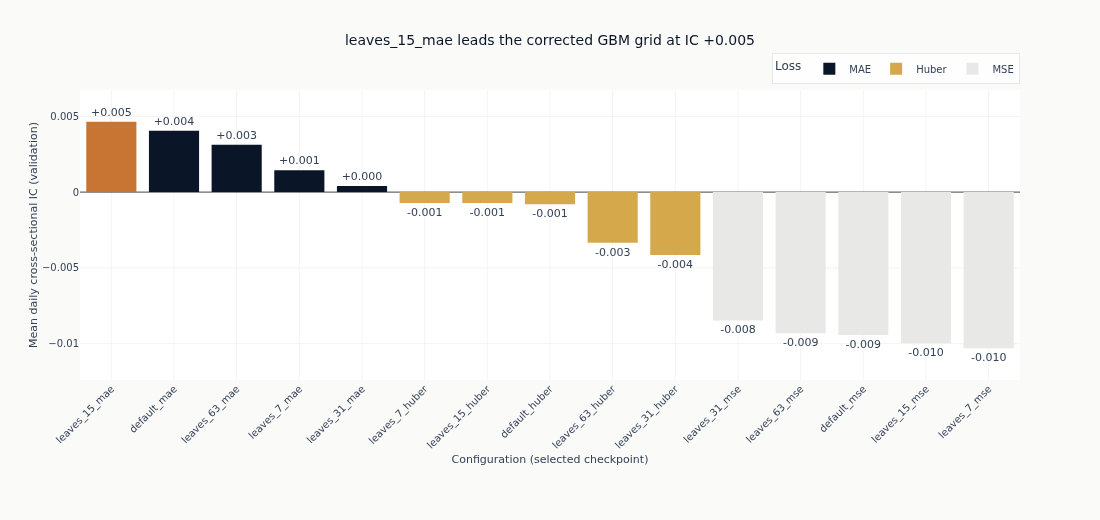

In [55]:
_names = [result["config"]["config_name"] for result in results]
_ics = [result["ic_mean"] for result in results]
_colors = [
    COLORS["copper"] if result is best else _LOSS_COLOR[_loss_of(result)] for result in results
]
fig_grid = go.Figure(
    go.Bar(
        x=_names,
        y=_ics,
        marker_color=_colors,
        text=[f"{value:+.3f}" for value in _ics],
        textposition="outside",
        cliponaxis=False,
        showlegend=False,
    )
)
for loss, color in _LOSS_COLOR.items():
    fig_grid.add_trace(go.Bar(x=[None], y=[None], marker_color=color, name=loss))
fig_grid.update_layout(
    title=(
        f"{best['config']['config_name']} leads the corrected GBM grid at IC {best['ic_mean']:+.3f}"
    ),
    template="ml4t",
    height=520,
    width=1100,
    margin=dict(t=90, b=140),
    legend=dict(title="Loss", orientation="h", y=1.02, x=1, xanchor="right", yanchor="bottom"),
    barmode="overlay",
)
fig_grid.update_xaxes(title_text="Configuration (selected checkpoint)", tickangle=-45)
fig_grid.update_yaxes(title_text="Mean daily cross-sectional IC (validation)", zeroline=True)
fig_grid.show()

### Learning curves

Every point uses the same endpoint-sealed daily validation timeline. Thin context
curves expose whether apparent gains persist or decay as boosting continues; the
selected grid winner is emphasized.

In [56]:
fig_lc = go.Figure()
for result in results:
    curve = all_curves.filter(pl.col("config") == result["config"]["config_name"]).sort("iteration")
    is_best = result is best
    fig_lc.add_trace(
        go.Scatter(
            x=curve["iteration"].to_list(),
            y=curve["ic_mean"].to_list(),
            mode="lines",
            line=dict(color=_LOSS_COLOR[_loss_of(result)], width=3 if is_best else 1),
            opacity=1.0 if is_best else 0.4,
            name=result["config"]["config_name"],
            showlegend=False,
            hovertemplate=f"{result['config']['config_name']}<br>trees %{{x}}<br>IC %{{y:+.4f}}<extra></extra>",
        )
    )
_ = fig_lc.add_trace(
    go.Scatter(
        x=[best["best_iter"]],
        y=[best["ic_mean"]],
        mode="markers",
        marker=dict(size=13, color=COLORS["copper"], line=dict(color=COLORS["slate"], width=1.5)),
        name="selected winner",
        showlegend=False,
    )
)

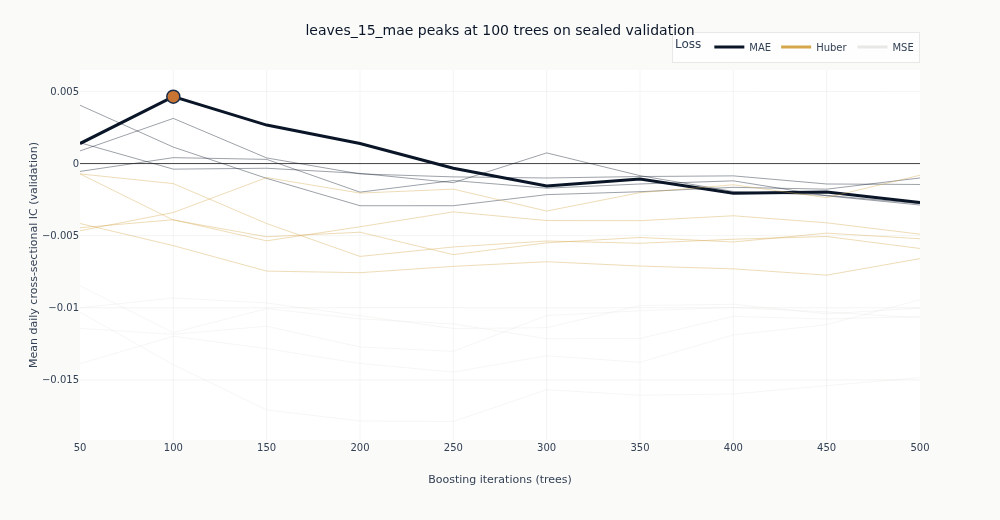

In [57]:
for loss, color in _LOSS_COLOR.items():
    fig_lc.add_trace(
        go.Scatter(x=[None], y=[None], mode="lines", line=dict(color=color, width=3), name=loss)
    )
fig_lc.update_layout(
    title=f"{best['config']['config_name']} peaks at {best['best_iter']} trees on sealed validation",
    template="ml4t",
    height=520,
    width=1000,
    margin=dict(t=70),
    legend=dict(title="Loss", orientation="h", y=1.02, x=1, xanchor="right", yanchor="bottom"),
)
fig_lc.update_xaxes(title_text="Boosting iterations (trees)")
fig_lc.update_yaxes(title_text="Mean daily cross-sectional IC (validation)", zeroline=True)
fig_lc.show()

## 5. Key Takeaways

The summary is generated from the current complete prediction panels. It keeps the
print-vintage number visible without substituting it for the corrected measurement.

In [58]:
_leader_q = all_curves.filter(
    (pl.col("config") == best["config"]["config_name"]) & (pl.col("iteration") == best["best_iter"])
)["q_value"][0]
_sign = "positive" if best["ic_mean"] > 0 else "negative" if best["ic_mean"] < 0 else "zero"
_fdr_text = (
    f"{fdr['n_rejected']}/{len(all_curves)} checkpoints survive 5% BH-FDR"
    if fdr["n_rejected"]
    else f"0/{len(all_curves)} checkpoints survive 5% BH-FDR"
)
_summary = f"""
### Measured GBM result

- **Current leader:** `{best["config"]["config_name"]}` at **{best["best_iter"]} trees** reaches
  daily IC **{best["ic_mean"]:+.4f}** across **{best["ic_n_days"]} dates**. Its 20-lag HAC
  statistic is **t={best["ic_t_hac"]:+.2f}**, **p={best["ic_p_hac"]:.4f}** and its grid-adjusted
  value is **q={_leader_q:.4f}**; {_fdr_text}.
- **Linear comparison:** the current GBM leader {comparison} `{linear_name}`
  (**{linear_ic:+.4f}**) by **{gbm_gain:+.4f} IC** on the same registry vintage.
- **Interpretation:** the leading association is **{_sign}**, but validation IC is not a trading
  return. The downstream equal-weight baseline and cost cascade decide whether it is economic.
- **Vintage context:** the printed table's **+0.0182** remains the original-run record; it is not
  substituted for this corrected deterministic CPU measurement.
"""
display(Markdown(_summary))


### Measured GBM result

- **Current leader:** `leaves_15_mae` at **100 trees** reaches
  daily IC **+0.0046** across **484 dates**. Its 20-lag HAC
  statistic is **t=+0.49**, **p=0.6234** and its grid-adjusted
  value is **q=0.9720**; 0/150 checkpoints survive 5% BH-FDR.
- **Linear comparison:** the current GBM leader improves on `enet_f0.7`
  (**-0.0039**) by **+0.0086 IC** on the same registry vintage.
- **Interpretation:** the leading association is **positive**, but validation IC is not a trading
  return. The downstream equal-weight baseline and cost cascade decide whether it is economic.
- **Vintage context:** the printed table's **+0.0182** remains the original-run record; it is not
  substituted for this corrected deterministic CPU measurement.


**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) tests attention-based tabular
models on the same sealed folds and return-to-expiry label.